# NoisiQ — Week 6 Notebook
**Noise-Aware Quantum Circuit Simulation and Visualization**
*Period: April 27 – May 3, 2026*

---

## Purpose of This Notebook

This notebook serves as the living record and demonstration for Week 6 of the NoisiQ project.

By the end of this notebook you should be able to:
- Apply T1 amplitude damping and T2/Tphi dephasing noise to a circuit
- Run a quantum trajectory simulation for non-Pauli noise
- Compare T1/T2 decay curves to expected exponential behavior
- Use the auto `BackendSelector` to dispatch to the correct simulator
- Run a T-gate circuit using `bloqade-tsim` via the Tsim backend

---

## Week 6 Milestone Summary

Week 6 introduces **non-Pauli decoherence** (T1/T2 channels via Kraus operators),
the **quantum trajectory backend** for Monte Carlo simulation, and **bloqade-tsim integration**
for T-gate circuits. The `BackendSelector` auto-dispatch is also implemented this week.
Also includes `test_randomized.py` moved from Week 5.

---

## Status Tracker

| Task | Owner | Status |
|------|-------|--------|
| `noisiq/backends/backend_selector.py` — auto-dispatch by gate set + noise type | TJ | ✅ Done |
| `noisiq/backends/tsim_backend.py` — `bloqade_tsim` wrapper | TJ | ✅ Done |
| `noisiq/noise/kraus_channels.py` — `KrausChannel` base + trace-preservation validator | TJ | ✅ Done |
| `noisiq/noise/amplitude_damping.py` — T1 channel (Kraus operators) | TJ | ✅ Done |
| `noisiq/noise/t2_dephasing.py` — T2/Tphi dephasing channel | TJ | ✅ Done |
| `noisiq/backends/trajectory_backend.py` — Monte Carlo quantum trajectories | TJ | ✅ Done |
| `tests/noise/test_kraus_channels.py` | TJ | ✅ Done |
| `tests/backends/test_trajectory.py` | TJ | ✅ Done |
| `tests/backends/test_randomized.py` — randomized Clifford correctness (moved from Week 5) | TJ | ✅ Done |
| All tests passing via `pytest` | TJ | ✅ Done |
| CI passing on GitHub | TJ | ✅ Done |
| Week 6 demo section of this notebook complete | TJ | ✅ Done |

---

## File Build Order

```
1. noisiq/noise/kraus_channels.py          ← KrausChannel base class (depends on numpy)
2. noisiq/noise/amplitude_damping.py       ← T1 channel (depends on kraus_channels)
3. noisiq/noise/t2_dephasing.py            ← T2 channel (depends on kraus_channels)
4. noisiq/backends/tsim_backend.py         ← Tsim wrapper (depends on bloqade_tsim)
5. noisiq/backends/trajectory_backend.py   ← MC trajectories (depends on kraus_channels)
6. noisiq/backends/backend_selector.py     ← Auto-dispatch (depends on all backends)
7. tests/noise/test_kraus_channels.py      ← Tests for (1), (2), (3)
8. tests/backends/test_trajectory.py       ← Tests for (5)
9. tests/backends/test_randomized.py       ← Randomized Clifford correctness (moved from Week 5)
```

---

## Physics Requirements for Week 6

**Kraus channel validity:**
- Must satisfy: `Σ_k K_k† K_k = I` (trace preservation)
- Must be completely positive (Kraus form guarantees this)

**T1 amplitude damping Kraus operators:**
```
K0 = [[1, 0], [0, sqrt(1 - gamma)]]   (no decay)
K1 = [[0, sqrt(gamma)], [0, 0]]        (decay to |0⟩)
where gamma = 1 - exp(-t / T1)
```

**T2 dephasing:** phase randomization at rate `1/T2 = 1/(2*T1) + 1/Tphi`

**Trajectory simulation:**
- Each shot: sample which Kraus operator applies (weighted by `||K_k |ψ⟩||²`)
- Apply selected Kraus operator and renormalize state
- Average density matrix over N trajectories: `ρ = (1/N) Σ |ψ_i⟩⟨ψ_i|`
- Practical limit: ~15 qubits before memory becomes prohibitive

**Backend auto-selection logic:**
```
if circuit has T/T_DAG/Rx/Ry/Rz/U3 gates:
    if noise is Pauli-only: use TsimBackend
    else: use TrajectoryBackend
elif circuit is Clifford-only:
    if noise is Pauli-only: use StimBackend
    else: use TrajectoryBackend
else:
    use AerBackend (if installed) or raise NotImplementedError
```

**Randomized correctness test protocol (`test_randomized.py`):**
- Generate ≥50 random Clifford circuits with seeded RNG
- Inject known Pauli errors at random locations
- Compare NoisiQ Pauli-frame output to direct Stim tableau output
- Assert output Pauli frames are identical

---

## Notes and Decisions Log

| Date | Note | Name |
|------|------|------|
| 2026-04-27 | Week 6 started. Using quantum trajectories (not full density matrix) for T1/T2. | DS |
| 2026-04-21 | test_randomized.py added to this week (moved from Week 5 to balance workload). | DS |
| | | |

# Installation Instructions (Developer)

```bash
pip install -e .
```

`bloqade-tsim` is now a core dependency and installs automatically.

noisiq 0.1.0 imported successfully

--- T1 Amplitude Damping Demo ---


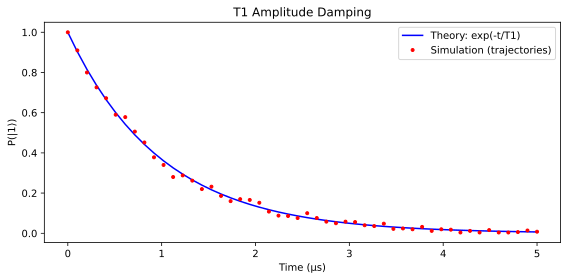


--- T-gate circuit via Tsim backend ---
Selected backend: TsimBackend
Simulation complete: SimulationResult(counts={'0': 823, '1': 177})


In [7]:
import noisiq as nq
import numpy as np
import matplotlib.pyplot as plt

print(f"noisiq {nq.__version__} imported successfully")

# 1. T1 amplitude damping: qubit decays to |0> over time
print("\n--- T1 Amplitude Damping Demo ---")
t_values = np.linspace(0, 5e-6, 50)   # 0 to 5 microseconds
T1 = 1e-6                              # 1 microsecond T1

# Theory: P(|1>) = exp(-t / T1)
theory = np.exp(-t_values / T1)

# Simulate decay via trajectory backend
circuit = nq.Circuit(n_qubits=1, name="t1_decay")
circuit.add_gate(nq.ir.X, qubits=[0])  # Prepare |1>

excited_probs = []
for t in t_values:
    noise = nq.noise.AmplitudeDamping(T1=T1, t=t)
    backend = nq.backends.BackendSelector.select(circuit, noise)
    result = backend.run(circuit, noise_model=noise, n_shots=500)
    excited_probs.append(result.excited_state_probability(qubit=0))

plt.figure(figsize=(8, 4))
plt.plot(t_values * 1e6, theory, 'b-', label='Theory: exp(-t/T1)')
plt.plot(t_values * 1e6, excited_probs, 'r.', label='Simulation (trajectories)')
plt.xlabel('Time (µs)')
plt.ylabel('P(|1⟩)')
plt.title('T1 Amplitude Damping')
plt.legend()
plt.tight_layout()
plt.show()

# 2. T-gate circuit via bloqade-tsim
print("\n--- T-gate circuit via Tsim backend ---")
t_circuit = nq.Circuit(n_qubits=1, name="t_gate_test")
t_circuit.add_gate(nq.ir.H, qubits=[0])
t_circuit.add_gate(nq.ir.T, qubits=[0])
t_circuit.add_gate(nq.ir.H, qubits=[0])

noise = nq.noise.DepolarizingChannel(p=0.005)
backend = nq.backends.BackendSelector.select(t_circuit, noise)
print(f"Selected backend: {type(backend).__name__}")
result = backend.run(t_circuit, noise_model=noise, n_shots=1000)
print(f"Simulation complete: {result}")

## 30-Qubit Clifford Circuit Demo

This demonstration showcases the package's ability to handle a large number of Clifford gates and visualize how errors propagate through an entangled 30-qubit circuit.


--- 30-Qubit Clifford Circuit Demo ---
Running clifford_30 with 59 operations...


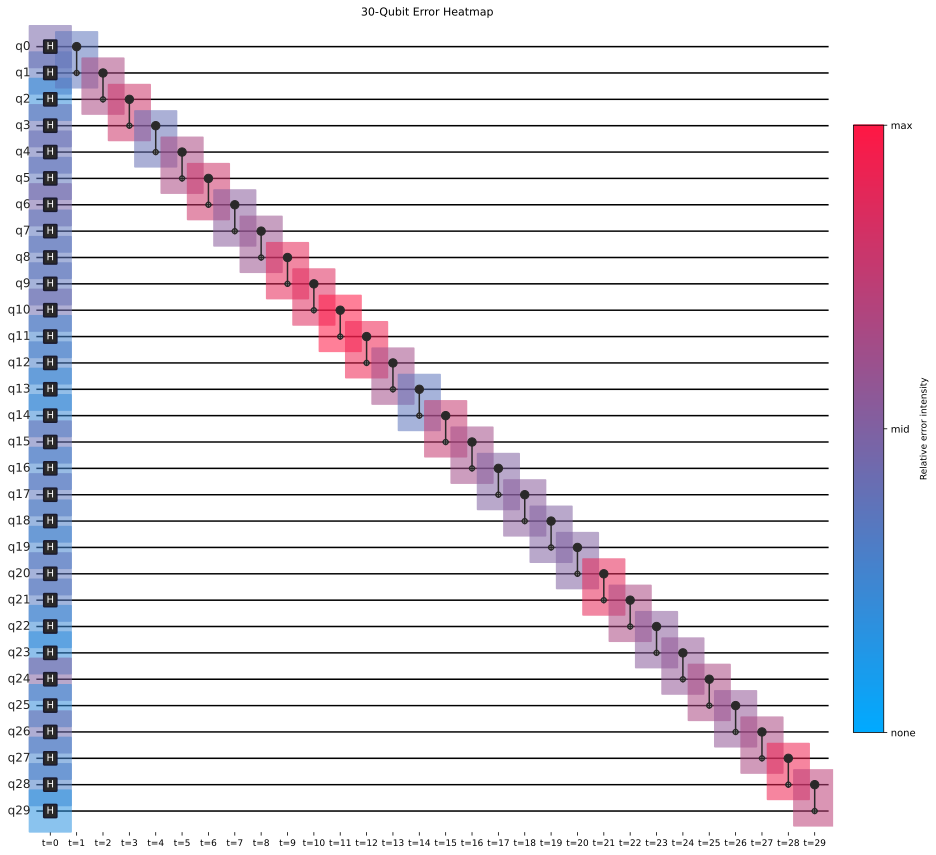

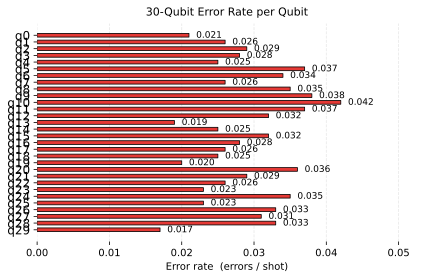

In [8]:
import noisiq as nq
from noisiq.backends.many_shot_runner import ManyShotRunner
from noisiq.noise import depolarizing_error
from noisiq.visualization.charts import plot_error_heatmap, plot_qubit_error_bar
import matplotlib.pyplot as plt

print("\n--- 30-Qubit Clifford Circuit Demo ---")
n_qubits = 30
circuit_30 = nq.Circuit(n_qubits=n_qubits, name="clifford_30")

# Layer of H gates
for i in range(n_qubits):
    circuit_30.add_gate(nq.ir.H, qubits=[i])

# Ladder of CX gates to entangle the state
for i in range(n_qubits - 1):
    circuit_30.add_gate(nq.ir.CNOT, qubits=[i, i+1])

# Configure ManyShotRunner with a depolarizing error
noise = depolarizing_error(p=0.01)
runner = ManyShotRunner()

# Run simulation
print(f"Running {circuit_30.name} with {len(circuit_30.operations)} operations...")
result_30 = runner.run(circuit_30, n_shots=1000, noise_config={i: noise for i in range(len(circuit_30.operations))})

# Visualize results
fig_heatmap = plot_error_heatmap(result_30, circuit_30, figsize=(15, 12), title="30-Qubit Error Heatmap")
plt.show()

fig_bar = plot_qubit_error_bar(result_30, title="30-Qubit Error Rate per Qubit")
plt.show()

## T-Gate Quantum Fourier Transform (QFT) Demo

This demonstration highlights the `TsimBackend`'s ability to handle non-Clifford `T` gates by implementing a 2-qubit Quantum Fourier Transform. The `CS` (controlled-S) gate is decomposed into `T`, `T_DAG`, and `CX` gates to be compatible with the backend.


--- 2-Qubit QFT Demo using TsimBackend ---
Selected backend for QFT: TsimBackend
QFT Measurement Counts: {'01': 261, '00': 246, '11': 237, '10': 256}


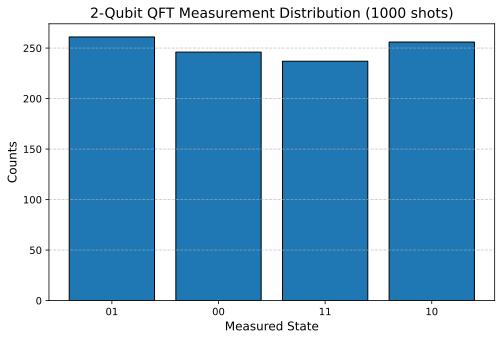

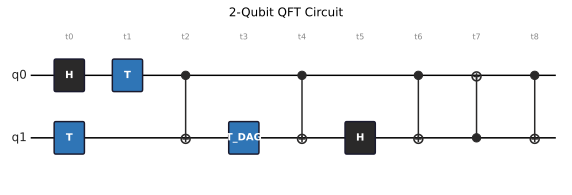

In [9]:
print("\n--- 2-Qubit QFT Demo using TsimBackend ---")

qft_circuit = nq.Circuit(n_qubits=2, name="qft_2")

# Apply H to qubit 0
qft_circuit.add_gate(nq.ir.H, qubits=[0])

# Implement CS(0, 1) using T, T_DAG, and CX
qft_circuit.add_gate(nq.ir.T, qubits=[0])
qft_circuit.add_gate(nq.ir.T, qubits=[1])
qft_circuit.add_gate(nq.ir.CNOT, qubits=[0, 1])
qft_circuit.add_gate(nq.ir.T_DAG, qubits=[1])
qft_circuit.add_gate(nq.ir.CNOT, qubits=[0, 1])

# Apply H to qubit 1
qft_circuit.add_gate(nq.ir.H, qubits=[1])

# SWAP(0, 1) using 3 CX gates
qft_circuit.add_gate(nq.ir.CNOT, qubits=[0, 1])
qft_circuit.add_gate(nq.ir.CNOT, qubits=[1, 0])
qft_circuit.add_gate(nq.ir.CNOT, qubits=[0, 1])

# Select backend and run
qft_noise = nq.noise.DepolarizingChannel(p=0.001)
qft_backend = nq.backends.BackendSelector.select(qft_circuit, qft_noise)
print(f"Selected backend for QFT: {type(qft_backend).__name__}")

qft_result = qft_backend.run(qft_circuit, noise_model=qft_noise, n_shots=1000)
print(f"QFT Measurement Counts: {qft_result.counts}")

import matplotlib.pyplot as plt

# Plotting the measurement counts
counts = qft_result.counts
states = list(counts.keys())
frequencies = list(counts.values())

plt.figure(figsize=(8, 5))
plt.bar(states, frequencies, color='#1f77b4', edgecolor='black')
plt.xlabel('Measured State', fontsize=12)
plt.ylabel('Counts', fontsize=12)
plt.title('2-Qubit QFT Measurement Distribution (1000 shots)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

from noisiq.visualization.circuit_diagram import draw_circuit

# Draw the QFT circuit
fig_qft, ax_qft = plt.subplots(figsize=(10, 3))
draw_circuit(ax_qft, qft_circuit, title="2-Qubit QFT Circuit")
plt.show()
